In [1]:
import sys
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from tqdm.auto import tqdm
from genkit.inspect import estimate_init_error, estimate_training_error, model_est_jacobian_spectral_curve
from genkit.metrics import metric_on_quantile, mssle
from labkit.report import PRETTY_RCPARAMS, summarize_metric_values, format_mean_std_latex


/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rcParams.update(PRETTY_RCPARAMS)


In [3]:
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src" / "genkit").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from benchmarks.analysis._utils import (
    METRIC_ORDER,
    aggregated_best_alpha,
    best_table_df,
    evaluate_run,
    load_generator,
    load_train_stats,
    reduce_best_alpha,
    reduce_best_alpha_runs,
    run_dirs,
    setting_code,
    summarize_exact,
    summarize_runs,
)
from benchmarks.runner._utils import select_entries


In [4]:
def grouped_violin(ax, series_by_label, title, ylabel, color="#4C72B0"):
    labels = list(series_by_label)
    values = [np.asarray(series_by_label[label], dtype=float) for label in labels]
    pos = np.arange(1, len(labels) + 1)
    violins = ax.violinplot(values, positions=pos, widths=0.8, showmeans=True, showextrema=False)
    for body in violins["bodies"]:
        body.set_alpha(0.28)
        body.set_facecolor(color)
        body.set_edgecolor(color)
    violins["cmeans"].set_color("black")
    for idx, vals in enumerate(values, start=1):
        jitter = np.linspace(-0.05, 0.05, len(vals)) if len(vals) > 1 else np.array([0.0])
        ax.scatter(np.full(len(vals), idx) + jitter, vals, s=12, alpha=0.7, color="black")
    ax.set_xticks(pos, labels)
    ax.tick_params(axis="x", labelrotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2, axis="y")


def styled_table(ax, cell_text, row_labels, col_labels, *, fontsize=8.5, scale=(1.0, 1.35), corner_text=None):
    ax.axis("off")
    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(*scale)
    if corner_text is not None:
        corner_width = table[(1, -1)].get_width() if (1, -1) in table.get_celld() else table[(1, 0)].get_width()
        corner_height = table[(0, 0)].get_height()
        table.add_cell(0, -1, width=corner_width, height=corner_height, text=corner_text, loc="center")
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("0.2")
        cell.set_linewidth(0.6)
        if row == 0 or col == -1:
            cell.set_text_props(weight="bold")
    return table


def average_curve(curves):
    if not curves:
        return None, None, None
    max_epoch = max(total_epochs for total_epochs, _ in curves)
    epoch_grid = np.arange(1, max_epoch + 1, dtype=float)
    aligned = []
    for total_epochs, curve in curves:
        x_curve = np.linspace(1.0, float(total_epochs), num=len(curve), dtype=float)
        aligned.append(np.interp(epoch_grid, x_curve, curve, left=np.nan, right=np.nan))
    stack = np.stack(aligned, axis=0)
    return epoch_grid, np.nanmean(stack, axis=0), np.nanstd(stack, axis=0)


In [5]:
config_path = repo_root / "benchmarks" / "configs" / "01_benchmark.yaml"
analysis_dir = repo_root / "benchmarks" / "analysis"
data_dir = analysis_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)

batch_dirs = sorted(path for path in data_dir.iterdir() if path.is_dir())
if not batch_dirs:
    raise FileNotFoundError(f"No benchmark batch found under {data_dir}")
batch_dir = batch_dirs[-1]
cache_path = Path("_metrics_cache_n4096_r3.csv")

device = "cuda" if torch.cuda.is_available() else "cpu"
n_eval_samples = 4096
n_repeats = 5
n_jobs = 2
parallel_backend = "threading"
inspect_samples = 2048
probe_size = 256
metric_order = METRIC_ORDER

config = yaml.safe_load(config_path.read_text())
active_model_entries = select_entries("models", config["models"], list(config["sweep"].get("models", [])))
active_model_names = {entry["entry_name"] for entry in active_model_entries}

print(f"device={device} | batch_dir={batch_dir} | n_runs={len(run_dirs(batch_dir))} | n_jobs={n_jobs} | backend={parallel_backend}")


device=cpu | batch_dir=/home/hcherkaoui/src/flowbench/benchmarks/analysis/data/1909387_01_benchmark | n_runs=324 | n_jobs=2 | backend=threading


In [6]:
manifest_paths = sorted(batch_dir.glob("manifest_shard_*.csv"))
summary_paths = sorted(batch_dir.glob("summary_shard_*.txt"))
run_paths = run_dirs(batch_dir)
checkpoint_paths = [run_dir for run_dir in run_paths if (run_dir / "checkpoint.pt").exists()]
shards_present = sorted(int(path.stem.split("_")[-1]) for path in manifest_paths)

if shards_present:
    all_shards = list(range(max(shards_present) + 1))
    missing_shards = [idx for idx in all_shards if idx not in shards_present]
else:
    missing_shards = []

print(f"n_runs={len(run_paths)}")
print(f"checkpoints={len(checkpoint_paths)}")
print(f"manifests={len(manifest_paths)} | summaries={len(summary_paths)} | missing_shards={missing_shards}")


n_runs=324
checkpoints=324
manifests=8 | summaries=8 | missing_shards=[]


In [7]:
if cache_path.exists():
    repeat_df = pd.read_csv(cache_path)
else:
    paths = [run_dir for run_dir in run_dirs(batch_dir) if (run_dir / "checkpoint.pt").exists()]
    rows_nested = Parallel(n_jobs=n_jobs, backend=parallel_backend)(
        delayed(evaluate_run)(run_dir, n_samples=n_eval_samples, n_repeats=n_repeats, device=device)
        for run_dir in tqdm(paths, desc="Evaluating runs")
    )
    repeat_df = pd.DataFrame([row for rows in rows_nested for row in rows])
    repeat_df.to_csv(cache_path, index=False)

repeat_df = repeat_df[repeat_df["model_name"].isin(active_model_names)].copy()
repeat_df["model_alpha"] = pd.to_numeric(repeat_df["model_alpha"], errors="coerce")
summary_exact = summarize_exact(repeat_df)
summary_exact = summary_exact[summary_exact["model_name"].isin(active_model_names)].copy()
summary_exact["model_alpha"] = pd.to_numeric(summary_exact["model_alpha"], errors="coerce")

failed_rows = []
for manifest_path in manifest_paths:
    manifest_df = pd.read_csv(manifest_path)
    if "status" in manifest_df.columns:
        failed_rows.append(manifest_df[manifest_df["status"] != "ok"].copy())
failed_df = pd.concat(failed_rows, ignore_index=True) if failed_rows else pd.DataFrame()

print(cache_path)
print(f"cached_rows={len(repeat_df)} | exact_rows={len(summary_exact)} | failed_manifest_rows={len(failed_df)}")
if len(failed_df):
    cols = [col for col in ["combo_index", "trial_idx", "model_preset", "train_preset", "status", "error_type"] if col in failed_df.columns]
    print(failed_df[cols].to_string(index=False))


_metrics_cache_n4096_r3.csv
cached_rows=648 | exact_rows=72 | failed_manifest_rows=0


In [8]:
run_summary = summarize_runs(repeat_df)
run_summary["model_alpha"] = pd.to_numeric(run_summary["model_alpha"], errors="coerce")

selected_runs = reduce_best_alpha_runs(run_summary, "W1")
selected_runs["model_alpha"] = pd.to_numeric(selected_runs["model_alpha"], errors="coerce")

style_map = {
    "GF-Linear": {"color": "tab:blue", "linestyle": "dashdot", "marker": "^", "loss_family": "MSE loss"},
    "DDPM-V": {"color": "tab:green", "linestyle": "solid", "marker": "o", "loss_family": "MSE loss"},
    "DLPM": {"color": "tab:purple", "linestyle": "dashed", "marker": "v", "loss_family": "sqrt(MSE) loss"},
    "DLPM-Orig": {"color": "tab:red", "linestyle": "dashed", "marker": "s", "loss_family": "sqrt(MSE) loss"},
    "FM-Orig": {"color": "tab:orange", "linestyle": "dashdot", "marker": "D", "loss_family": "MSE loss"},
}
label_order = [label for label in style_map if label in set(selected_runs["model_label"])]
source_order = label_order
loss_groups = {}
for label in label_order:
    loss_groups.setdefault(style_map[label]["loss_family"], []).append(label)

xis = np.unique(np.round(1 - np.logspace(-1, -3, 7), 6))
train_curves = {label: {"training_loss": [], "grad_variance_epoch": [], "grad_norm_epoch": []} for label in label_order}
inspect_rows = []
jacobian_runs = {label: [] for label in label_order}
tail_runs = {label: [] for label in label_order}
failures = []

for _, row in tqdm(selected_runs.iterrows(), total=len(selected_runs), desc="Inspecting selected runs"):
    run_dir = batch_dir / row["run_dir"]
    model_label = row["model_label"]
    try:
        stats = load_train_stats(run_dir)
        run_config = yaml.safe_load((run_dir / "config.yaml").read_text())
        total_epochs = int(run_config["train"]["n_epochs"])
        for key in ["training_loss", "grad_variance_epoch", "grad_norm_epoch"]:
            curve = stats[key].to_numpy(dtype=float)
            if len(curve):
                train_curves[model_label][key].append((total_epochs, curve))

        generator, x_test, _ = load_generator(run_dir, device=device)
        x_ref = x_test[: min(inspect_samples, len(x_test)), :]
        x_gen = generator.sample(n_samples=len(x_ref))
        mssle_curve = np.array([
            metric_on_quantile(mssle, x_ref, x_gen, xi=float(xi), reduction="mean")
            for xi in xis
        ])
        tail_runs[model_label].append(mssle_curve)

        err_init = estimate_init_error(generator, x_ref, n_samples=min(4096, len(x_ref)), k=10)
        err_train = estimate_training_error(generator, x_ref, n_batches=16, batch_size=min(256, len(x_ref)))
        inspect_rows.append({"model_label": model_label, "err_init": err_init, "err_train": err_train})

        x_probe = x_ref[: min(probe_size, len(x_ref)), :]
        jac_curve, _ = model_est_jacobian_spectral_curve(generator, x_probe, n_power_iter=8, max_n_steps=10)
        if model_label in {"GF-Linear", "FM-Orig"}:
            jac_curve = jac_curve[::-1]
        jacobian_runs[model_label].append(np.asarray(jac_curve, dtype=float))
    except Exception as exc:
        failures.append({"run_dir": row["run_dir"], "model_label": model_label, "error": str(exc)})

if failures:
    for failure in failures[:10]:
        print(f"{failure['model_label']} | {failure['run_dir']} | {failure['error']}")
    if len(failures) > 10:
        print(f"... {len(failures) - 10} more failures")

inspect_df = pd.DataFrame(inspect_rows)
inspect_summary = pd.DataFrame({
    "err_init": {label: summarize_metric_values(inspect_df.loc[inspect_df["model_label"] == label, "err_init"].tolist()) for label in label_order},
    "err_train": {label: summarize_metric_values(inspect_df.loc[inspect_df["model_label"] == label, "err_train"].tolist()) for label in label_order},
})


Inspecting selected runs: 100%|██████████| 48/48 [23:12<00:00, 29.02s/it] 

DLPM-Orig | 102_alpha_stable_target__alpha-1p5__dim-30__mlp_medium__dlpm_eps_origin__alpha-2p0__long__trial-03 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
DLPM-Orig | 097_alpha_stable_target__alpha-1p5__dim-30__mlp_medium__dlpm_eps_origin__alpha-2p0__short__trial-01 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
DLPM-Orig | 048_alpha_stable_target__alpha-1p5__dim-30__mlp_small__dlpm_eps_origin__alpha-2p0__long__trial-03 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
DLPM-Orig | 044_alpha_stable_target__alpha-1p5__dim-30__mlp_small__dlpm_eps_origin__alpha-2p0__short__trial-02 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
FM-Orig | 106_alpha_stable_target__alpha-1p5__dim-30__mlp_medium__flow_matching_origin__long__trial-01 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
FM-Orig | 103_alpha_stable_target__alpha-1p5__di

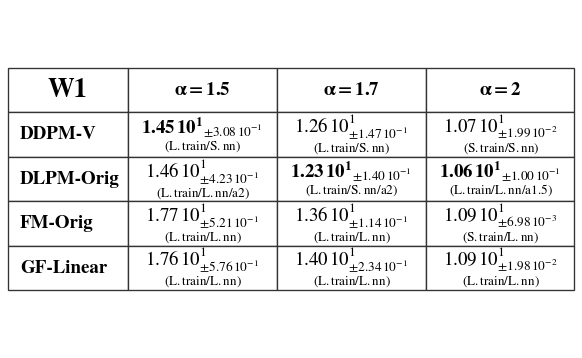

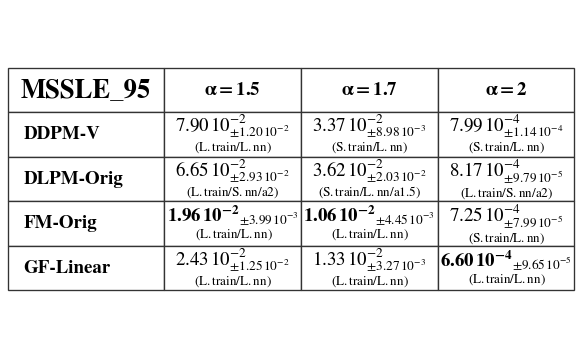

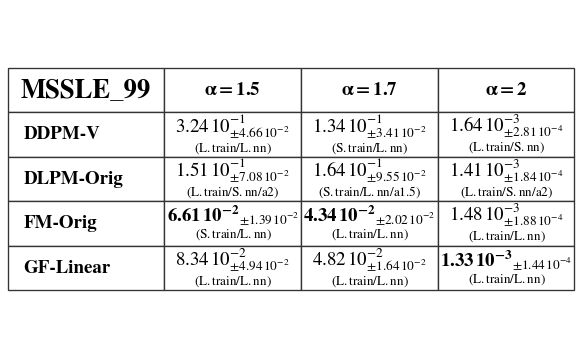

In [9]:
for metric in metric_order:
    winners = best_table_df(summary_exact, metric)
    table = pd.DataFrame(
        index=sorted(winners["model_label"].unique()),
        columns=sorted(winners["dataset_alpha"].unique()),
        dtype=object,
    )
    for dataset_alpha, group in winners.groupby("dataset_alpha"):
        best_model = group.nsmallest(1, f"{metric}_mean").iloc[0]["model_label"]
        for _, row in group.iterrows():
            table.loc[row["model_label"], dataset_alpha] = format_mean_std_latex(
                row[f"{metric}_mean"],
                row[f"{metric}_std"],
                caption=setting_code(row),
                bold=row["model_label"] == best_model,
            )

    fig, ax = plt.subplots(1, 1, figsize=(0.9 + len(table.columns), 0.9 + 0.4 * len(table.index)))
    styled_table(
        ax,
        table.values,
        list(table.index),
        [rf"$\mathbf{{\alpha={alpha:.3g}}}$" for alpha in table.columns],
        fontsize=8.5,
        scale=(1.0, 1.5),
        corner_text=metric,
    )
    fig.tight_layout()
    plt.show()


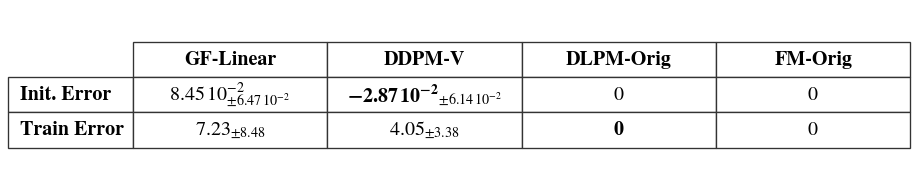

In [10]:
inspect_table = pd.DataFrame(index=["Init. Error", "Train Error"], columns=label_order, dtype=object)
best_by_inspect = {
    metric_name: inspect_summary[metric_name].map(lambda d: d["mean"]).idxmin()
    for metric_name in ["err_init", "err_train"]
}

for model_label in label_order:
    inspect_table.loc["Init. Error", model_label] = format_mean_std_latex(
        inspect_summary.loc[model_label, "err_init"]["mean"],
        inspect_summary.loc[model_label, "err_init"]["std"],
        bold=model_label == best_by_inspect["err_init"],
    )
    inspect_table.loc["Train Error", model_label] = format_mean_std_latex(
        inspect_summary.loc[model_label, "err_train"]["mean"],
        inspect_summary.loc[model_label, "err_train"]["std"],
        bold=model_label == best_by_inspect["err_train"],
    )

fig, ax = plt.subplots(1, 1, figsize=(1.25 * len(label_order) + 1.0, 1.45))
styled_table(ax, inspect_table.values, list(inspect_table.index), label_order, fontsize=9, scale=(1.0, 1.35))
fig.tight_layout()
plt.show()


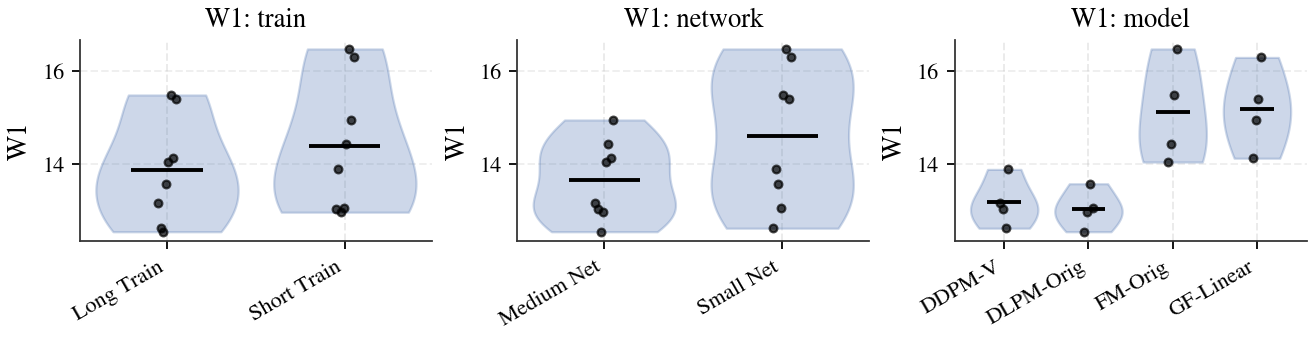

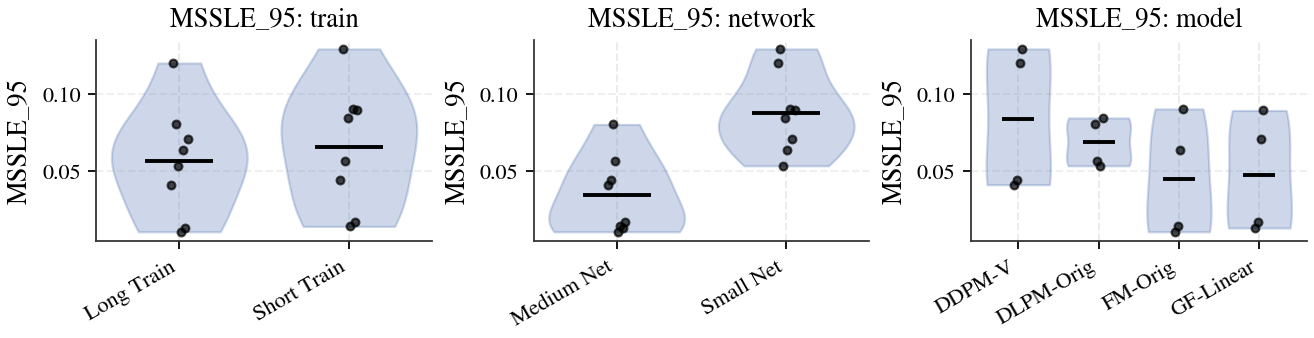

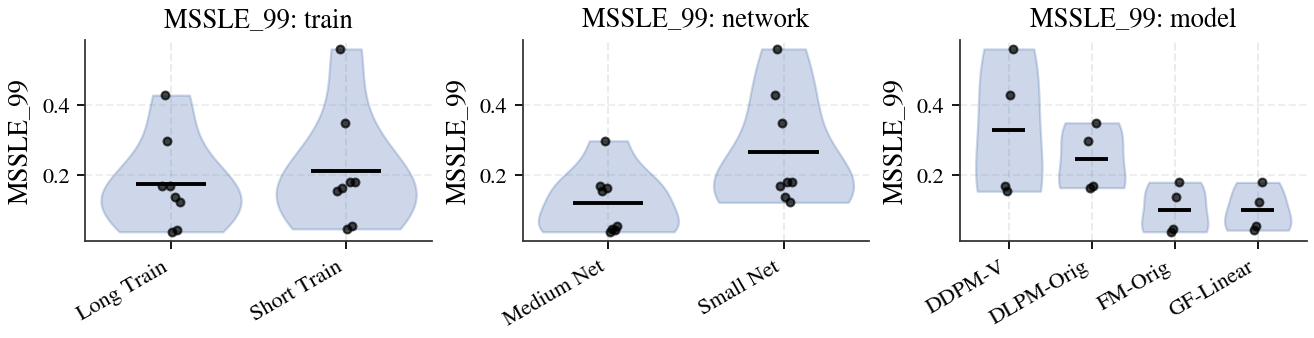

In [11]:
label_maps = {
    "train_preset": {"short": "Short Train", "long": "Long Train"},
    "network_preset": {"mlp_small": "Small Net", "mlp_medium": "Medium Net"},
}

for metric in ["W1", "MSSLE_95", "MSSLE_99"]:
    agg = aggregated_best_alpha(summary_exact, metric)
    groups = [
        ("train_preset", f"{metric}: train"),
        ("network_preset", f"{metric}: network"),
        ("model_label", f"{metric}: model"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(8.2, 2.1), constrained_layout=True)
    for ax, (column, title) in zip(axes, groups):
        label_map = label_maps.get(column, {})
        series_by_label = {label_map.get(key, key): grp[metric].to_numpy() for key, grp in agg.groupby(column)}
        grouped_violin(ax, series_by_label, title, metric)
    plt.show()


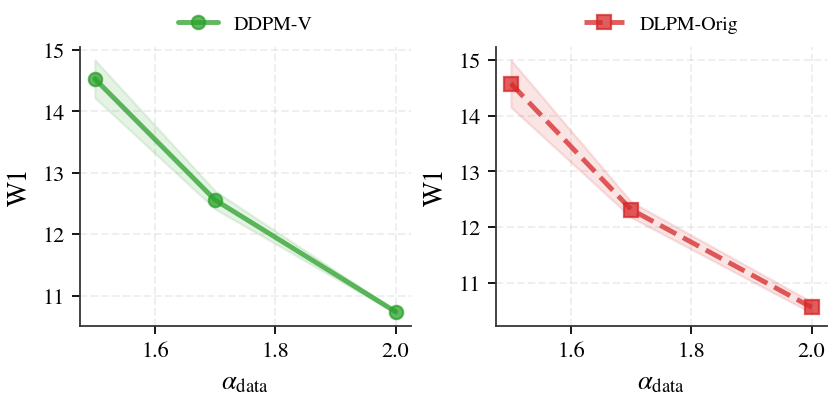

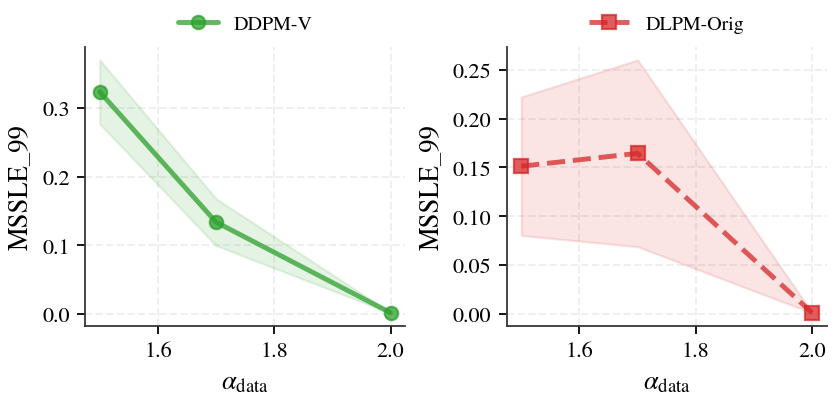

In [18]:
source_pairs = [("DDPM-V", "DLPM", "Diffusion baselines"), ("DLPM", "DLPM-Orig", "Native vs origin")]

for metric in ["W1", "MSSLE_99"]:
    reduced = reduce_best_alpha(summary_exact, metric)
    best_over_net_train = (
        reduced.sort_values(f"{metric}_mean")
        .groupby(["dataset_alpha", "model_label"], dropna=False)
        .first()
        .reset_index()
    )
    fig, axes = plt.subplots(1, len(source_pairs), figsize=(2.6 * len(source_pairs), 2.5), constrained_layout=True, squeeze=False)
    for ax, (left_model, right_model, title) in zip(axes.flat, source_pairs):
        sub = best_over_net_train[best_over_net_train["model_label"].isin([left_model, right_model])]
        for model_label, group in sub.groupby("model_label"):
            group = group.sort_values("dataset_alpha")
            style = style_map[model_label]
            means = group[f"{metric}_mean"].to_numpy(dtype=float)
            stds = group[f"{metric}_std"].to_numpy(dtype=float)
            x = group["dataset_alpha"].to_numpy(dtype=float)
            ax.plot(x, means, marker=style["marker"], lw=2.2, color=style["color"], linestyle=style["linestyle"], label=model_label, alpha=0.75)
            ax.fill_between(x, means - stds, means + stds, color=style["color"], alpha=0.12)
        ax.set_xlabel(r"$\alpha_{\mathrm{data}}$")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.2)
        ax.legend(ncol=1, loc="upper center", bbox_to_anchor=(0.5, 1.18), frameon=False, fontsize=9)
    plt.show()


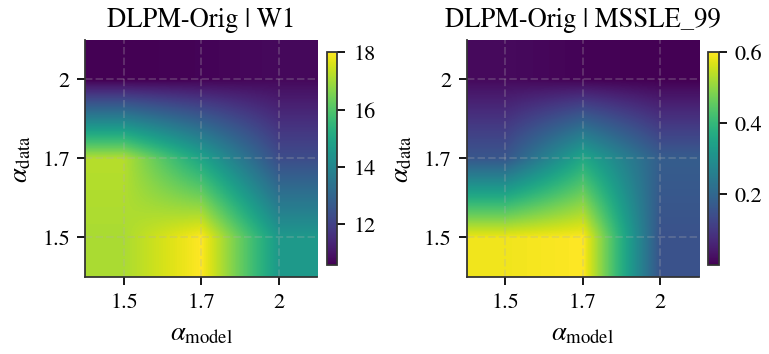

In [13]:
for model_label in [label for label in ["DLPM", "DLPM-Orig"] if label in set(summary_exact["model_label"])]:
    fig, axes = plt.subplots(1, 2, figsize=(4.8, 2.2), constrained_layout=True)
    sub = summary_exact[summary_exact["model_label"] == model_label].copy()
    for ax, metric in zip(axes, ["W1", "MSSLE_99"]):
        best = (
            sub.sort_values(f"{metric}_mean")
            .groupby(["dataset_alpha", "model_alpha"], dropna=False)
            .first()
            .reset_index()
        )
        pivot = best.pivot(index="dataset_alpha", columns="model_alpha", values=f"{metric}_mean").sort_index().sort_index(axis=1)
        image = ax.imshow(pivot.values, origin="lower", aspect="auto", interpolation="bilinear")
        ax.set_title(f"{model_label} | {metric}")
        ax.set_xlabel(r"$\alpha_{\mathrm{model}}$")
        ax.set_ylabel(r"$\alpha_{\mathrm{data}}$")
        ax.set_xticks(np.arange(len(pivot.columns)), [f"{x:.3g}" for x in pivot.columns])
        ax.set_yticks(np.arange(len(pivot.index)), [f"{x:.3g}" for x in pivot.index])
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


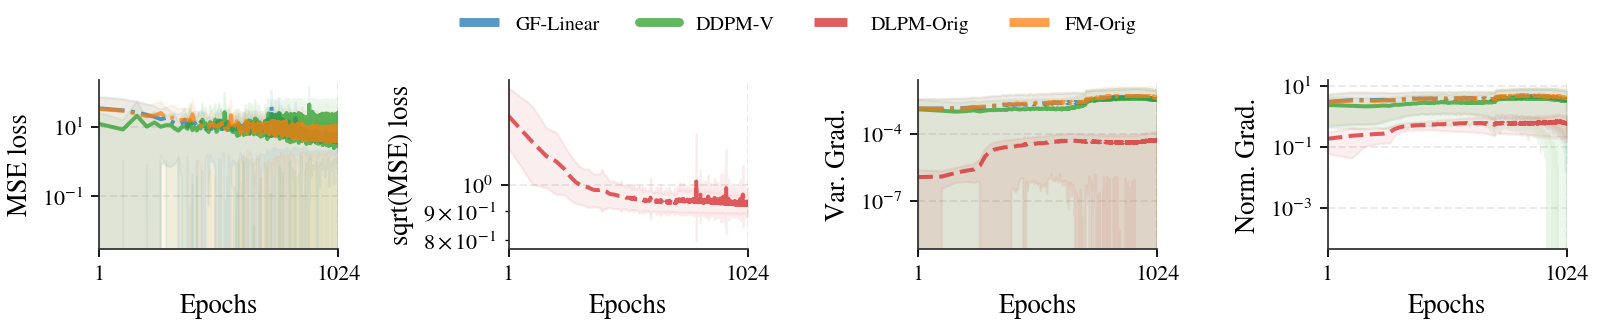

In [14]:
loss_by_model = {label: average_curve(train_curves[label]["training_loss"]) for label in label_order}
grad_var_by_model = {label: average_curve(train_curves[label]["grad_variance_epoch"]) for label in label_order}
grad_norm_by_model = {label: average_curve(train_curves[label]["grad_norm_epoch"]) for label in label_order}
max_grad_var_epochs = max(epochs[-1] for epochs, curve, std in grad_var_by_model.values() if epochs is not None and curve is not None)
max_grad_norm_epochs = max(epochs[-1] for epochs, curve, std in grad_norm_by_model.values() if epochs is not None and curve is not None)

fig, axes = plt.subplots(1, len(loss_groups) + 2, figsize=(3.0 * len(loss_groups) + 4.25, 2.1), squeeze=False)

for idx, loss_label in enumerate(loss_groups):
    ax = axes[0, idx]
    model_names = loss_groups[loss_label]
    max_epochs = max(loss_by_model[name][0][-1] for name in model_names if loss_by_model[name][0] is not None)
    for name in model_names:
        epochs, curve, std = loss_by_model[name]
        if curve is None:
            continue
        style = style_map[name]
        ax.plot(epochs, curve, color=style["color"], linestyle=style["linestyle"], lw=1.8, alpha=0.75)
        ax.fill_between(epochs, curve - std, curve + std, color=style["color"], alpha=0.08)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1, max_epochs)
    ax.set_xticks([1, max_epochs], ["1", f"{int(max_epochs)}"])
    ax.set_xlabel("Epochs")
    ax.set_ylabel(loss_label)

for name in label_order:
    style = style_map[name]
    epochs, curve, std = grad_var_by_model[name]
    if curve is not None:
        axes[0, -2].plot(epochs, curve, color=style["color"], linestyle=style["linestyle"], lw=1.8, alpha=0.75)
        axes[0, -2].fill_between(epochs, curve - std, curve + std, color=style["color"], alpha=0.08)
    epochs, curve, std = grad_norm_by_model[name]
    if curve is not None:
        axes[0, -1].plot(epochs, curve, color=style["color"], linestyle=style["linestyle"], lw=1.8, alpha=0.75)
        axes[0, -1].fill_between(epochs, curve - std, curve + std, color=style["color"], alpha=0.08)

axes[0, -2].set_xscale("log")
axes[0, -2].set_yscale("log")
axes[0, -2].set_xlim(1, max_grad_var_epochs)
axes[0, -2].set_xticks([1, max_grad_var_epochs], ["1", f"{int(max_grad_var_epochs)}"])
axes[0, -2].set_xlabel("Epochs")
axes[0, -2].set_ylabel("Var. Grad.")

axes[0, -1].set_xscale("log")
axes[0, -1].set_yscale("log")
axes[0, -1].set_xlim(1, max_grad_norm_epochs)
axes[0, -1].set_xticks([1, max_grad_norm_epochs], ["1", f"{int(max_grad_norm_epochs)}"])
axes[0, -1].set_xlabel("Epochs")
axes[0, -1].set_ylabel("Norm. Grad.")

legend_handles = [
    Line2D([0], [0], color=style_map[label]["color"], lw=4.0, linestyle=style_map[label]["linestyle"], label=label, alpha=0.75)
    for label in label_order
]
fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=len(label_order), frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1.0, 0.88))
plt.show()


In [15]:
# Obsolete duplicate cell removed.


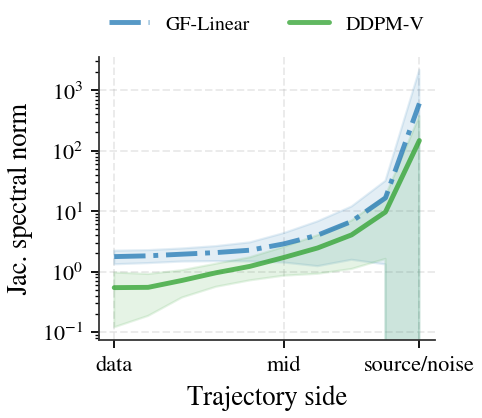

In [16]:
fig, ax = plt.subplots(figsize=(3.0, 2.6), constrained_layout=True)
for label in label_order:
    curves = jacobian_runs[label]
    if not curves:
        continue
    min_len = min(len(curve) for curve in curves)
    stack = np.stack([curve[:min_len] for curve in curves], axis=0)
    avg_curve = stack.mean(axis=0)
    std_curve = stack.std(axis=0)
    x = np.arange(min_len)
    style = style_map[label]
    ax.plot(x, avg_curve, color=style["color"], linestyle=style["linestyle"], lw=2.2, alpha=0.75, label=label)
    ax.fill_between(x, avg_curve - std_curve, avg_curve + std_curve, color=style["color"], alpha=0.12)

if any(jacobian_runs[label] for label in label_order):
    n_pts = min(len(curve) for label in label_order for curve in jacobian_runs[label])
    ax.set_xticks([0, n_pts // 2, n_pts - 1], ["data", "mid", "source/noise"])
ax.set_yscale("log")
ax.set_xlabel("Trajectory side")
ax.set_ylabel("Jac. spectral norm")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=9)
plt.show()


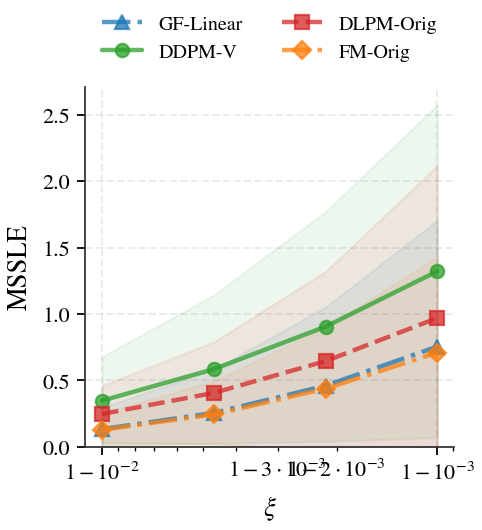

In [17]:
start = 3
fig, ax = plt.subplots(figsize=(3.0, 3.3), constrained_layout=True)
for label in label_order:
    curves = tail_runs[label]
    if not curves:
        continue
    stack = np.stack(curves, axis=0)
    avg_curve = stack.mean(axis=0)[start:]
    std_curve = stack.std(axis=0)[start:]
    style = style_map[label]
    ax.plot(xis[start:], avg_curve, color=style["color"], linestyle=style["linestyle"], marker=style["marker"], lw=2.0, alpha=0.75, label=label)
    ax.fill_between(xis[start:], avg_curve - std_curve, avg_curve + std_curve, color=style["color"], alpha=0.08)

ax.set_xscale("logit")
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$\xi$")
ax.set_ylabel("MSSLE")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=9)
plt.show()
